In [36]:
import joblib
import pandas as pd
import numpy as np

In [37]:
model = joblib.load("../models/best_model.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

In [38]:
feature_names = vectorizer.get_feature_names_out()

In [39]:
feature_names = list(vectorizer.get_feature_names_out())

feature_names.extend([
    "telecommuting",
    "has_company_logo",
    "has_questions"
])

In [ ]:
print(len(feature_names))
coef = model.coef_[0]
print(len(coef))

5003
5003


In [41]:
print("Feature names:", len(feature_names))
print("Coefficient shape:", model.coef_.shape)
print("Coefficient length:", len(coef))

Feature names: 5003
Coefficient shape: (1, 5003)
Coefficient length: 5003


In [42]:
importance = pd.DataFrame({
    "Word": feature_names,
    "Weight": coef
})

In [43]:
top_positive = importance.sort_values("Weight", ascending=False).head(20)
top_positive

,Word,Weight
232,aptitude,7.233955
2000,high school,7.044200
2771,money,6.860814
4295,subsea,6.739297
2931,ohio,6.336404
4033,signing,5.777304
210,apply,5.693798
772,compensation package,5.604992
2929,offshore,5.514513
2849,networking,5.387217


In [44]:
top_negative = importance.sort_values("Weight").head(20)
top_negative

,Word,Weight
745,companies,-6.024358
1433,english,-5.466503
1940,handling,-4.912797
1552,exceptional,-4.662764
4393,team,-4.458069
1010,custom,-4.319444
1803,fun,-4.262957
856,consultants,-4.256482
1910,growing,-4.240057
3900,search,-4.209645


In [45]:
importance.sort_values(
    by="Weight",
    ascending=False
).head(20)

,Word,Weight
232,aptitude,7.233955
2000,high school,7.044200
2771,money,6.860814
4295,subsea,6.739297
2931,ohio,6.336404
4033,signing,5.777304
210,apply,5.693798
772,compensation package,5.604992
2929,offshore,5.514513
2849,networking,5.387217


In [46]:
importance.sort_values(
    by="Weight"
).head(20)

,Word,Weight
745,companies,-6.024358
1433,english,-5.466503
1940,handling,-4.912797
1552,exceptional,-4.662764
4393,team,-4.458069
1010,custom,-4.319444
1803,fun,-4.262957
856,consultants,-4.256482
1910,growing,-4.240057
3900,search,-4.209645


In [47]:
import matplotlib.pyplot as plt

In [48]:
top_real = importance.sort_values(
    by="Weight",
    ascending=False
).head(15)

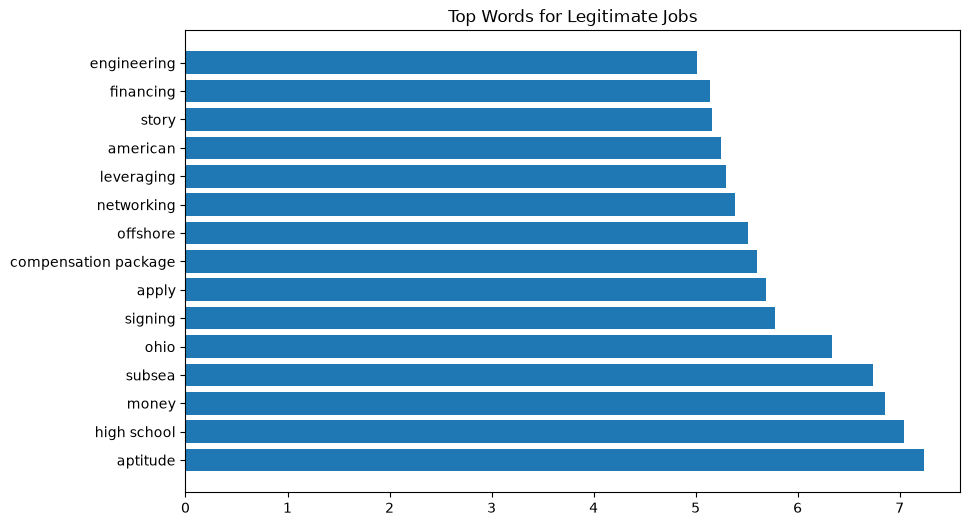

In [49]:
plt.figure(figsize=(10,6))

plt.barh(
    top_real["Word"],
    top_real["Weight"]
)

plt.title("Top Words for Legitimate Jobs")

plt.show()

In [50]:
top_fake = importance.sort_values(
    by="Weight"
).head(15)

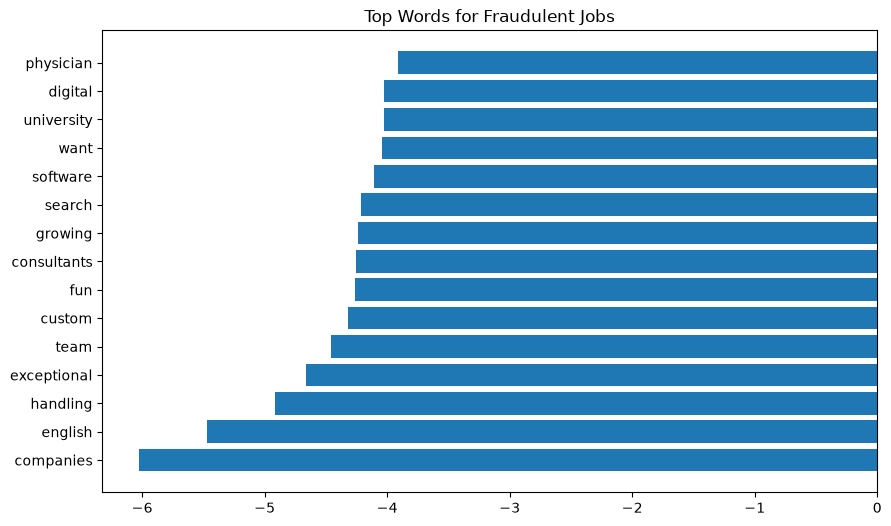

In [51]:
plt.figure(figsize=(10,6))

plt.barh(
    top_fake["Word"],
    top_fake["Weight"]
)

plt.title("Top Words for Fraudulent Jobs")

plt.show()